# Understanding the Data

**The business problem.** A grocery retailer sends coupon offers to households. Today the same popular offers go to almost everyone, so most coupons land with people who would not have bought the product anyway. We want to give each household a short, personalised list of products to offer a coupon for — products that household is genuinely likely to buy soon.

**How we will judge it.** We take the final stretch of the two-year history and hide it. Everything is built on the earlier data; then we check, for each household, how many of the products we picked it actually bought in that hidden stretch. A method that predicts better than a plain "everyone gets the bestsellers" rule is adding value.

**Why this notebook comes first.** Before choosing a method we need to know what the data can and cannot support. Seven practical questions: Is the data clean? What can we even put a coupon on? How much history does a typical household have? Is demand concentrated on a few products or spread thin? How does the retailer target coupons today (what do we have to beat)? Is the hidden test stretch a normal period? And what does a realistic "correct answer" look like?

**The split.** The two years are divided in advance so the method cannot be tuned to the test data after seeing it: an early **training** stretch to learn from, a short **validation** stretch to tune settings, and a final **test** stretch left untouched until the end.

## 1. Load the data

We use three main files:

- **purchases** — one row per product per shopping trip, for 2,500 households over ~2 years (about 2.6 million rows);
- **product list** — the full catalogue (~92,000 products); each product rolls up into a broad *commodity* (e.g. "yogurt") and a *department* (e.g. "dairy");
- **coupon list** — which products each coupon can be redeemed against.

Two more files are loaded later, for context only: the **campaign** and **redemption** records (who was sent which campaign, and what they redeemed). A sixth file, `causal_data.csv` (~37M rows of in-store display and mailer flags), is not used in this study.

We also confirm the raw files match the published dataset, and print the fixed train / validation / test split.

In [40]:
# --- find the project folder so the shared code in `src/` can be imported ---
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for c in [start, *start.parents]:
        if (c / "src").is_dir() and (c / "Data").is_dir():
            return c
    raise FileNotFoundError("repo root not found")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The train / validation / test weeks are fixed in src/config.py and are NOT changed
# here — keeping them fixed is what makes the final score honest.
from src.config import DATA_DIR, TRAIN_WEEKS, VAL_WEEKS, TEST_WEEKS, SEED
from src.data_loader import load_transactions, load_product

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# --- load the three main tables ---
transactions = load_transactions()                     # every purchase line
product      = load_product()                          # the product catalogue
coupon       = pd.read_csv(DATA_DIR / "coupon.csv")    # which products each coupon covers

# --- headline size numbers (these go straight into the report) ---
print(f"transaction rows    : {len(transactions):,}")
print(f"households           : {transactions['household_key'].nunique():,}")
print(f"products (catalogue) : {product['PRODUCT_ID'].nunique():,}")
print(f"coupon rows          : {len(coupon):,}")
print(f"weeks               : {transactions['WEEK_NO'].min()} - {transactions['WEEK_NO'].max()}")
print(f"split               : train {TRAIN_WEEKS[0]}-{TRAIN_WEEKS[-1]}  "
      f"val {VAL_WEEKS[0]}-{VAL_WEEKS[-1]}  test {TEST_WEEKS[0]}-{TEST_WEEKS[-1]}")

transaction rows    : 2,595,732
households           : 2,500
products (catalogue) : 92,353
coupon rows          : 124,548
weeks               : 1 - 102
split               : train 1-79  val 80-84  test 85-102


In [41]:
# --- do the raw files match the published dataset? ---
# Count rows without loading the large files, and compare to the documented
# Kaggle "Complete Journey" sizes. A file off by more than ~2x would mean it was
# truncated or re-exported, and every number below would be suspect.
def count_rows(path: Path) -> int:
    with open(path, "rb") as f:
        return sum(chunk.count(b"\n") for chunk in iter(lambda: f.read(1 << 20), b"")) - 1


expected = {
    "transaction_data.csv": 2_600_000,
    "product.csv":             92_000,
    "coupon.csv":             124_000,
    "coupon_redempt.csv":       2_300,
    "hh_demographic.csv":         800,
    "causal_data.csv":     36_000_000,
}
for fname, exp in expected.items():
    actual = count_rows(DATA_DIR / fname)
    ratio = actual / exp
    flag = "OK" if 0.5 <= ratio <= 2.0 else "CHECK"
    print(f"{fname:<22s} rows={actual:>11,}  vs ~{exp:>11,}  ({ratio:.2f}x)  {flag}")

transaction_data.csv   rows=  2,595,732  vs ~  2,600,000  (1.00x)  OK
product.csv            rows=     92,353  vs ~     92,000  (1.00x)  OK
coupon.csv             rows=    124,548  vs ~    124,000  (1.00x)  OK
coupon_redempt.csv     rows=      2,318  vs ~      2,300  (1.01x)  OK
hh_demographic.csv     rows=        801  vs ~        800  (1.00x)  OK
causal_data.csv        rows= 36,786,524  vs ~ 36,000,000  (1.02x)  OK


## 2. Is the data clean enough to trust?

Every later number is built on these records, so we first rule out the mistakes that would quietly poison the results:

- **missing values** — gaps in key fields;
- **duplicate rows** — the same purchase counted twice, which would inflate how often a product looks bought;
- **impossible values** — zero or negative quantities and prices;
- **broken links** — a purchase or coupon that points to a product not in the catalogue.

If any of these were large, we would have to clean or drop rows before trusting anything downstream.

In [42]:
# Check every column of every table for gaps. A gap in household_key, PRODUCT_ID or
# WEEK_NO would break the analysis.
for name, df in [("transactions", transactions), ("product", product), ("coupon", coupon)]:
    miss = df.isna().sum()
    miss = miss[miss > 0]
    print(f"{name:<13s}: {'none' if miss.empty else miss.to_dict()}")

transactions : none
product      : none
coupon       : none


In [43]:
# --- duplicates: same household + same trip + same product + same day, counted twice ---
dup_key = ["household_key", "BASKET_ID", "PRODUCT_ID", "DAY"]
n_dup = int(transactions.duplicated(dup_key, keep=False).sum())

q  = transactions["QUANTITY"]      # units bought on the line
sv = transactions["SALES_VALUE"]   # money the retailer received for the line
valid_products = set(product["PRODUCT_ID"])

# QUANTITY <= 0 and SALES_VALUE == 0 are odd lines (returns, giveaways, glitches);
# we exclude them later rather than count them as real purchases.
print(f"duplicate transaction lines             : {n_dup:,}  ({n_dup / len(transactions):.3%})")
print(f"QUANTITY <= 0                            : {int((q <= 0).sum()):,}  ({(q <= 0).mean():.3%})")
print(f"SALES_VALUE < 0 (returns)               : {int((sv < 0).sum()):,}  ({(sv < 0).mean():.3%})")
print(f"SALES_VALUE == 0                         : {int((sv == 0).sum()):,}  ({(sv == 0).mean():.3%})")
# broken links -> a purchase / coupon we could not tie back to a catalogue product
print(f"tx rows w/ PRODUCT_ID not in product.csv : {int((~transactions['PRODUCT_ID'].isin(valid_products)).sum()):,}")
print(f"coupon rows w/ PRODUCT_ID not in product : {int((~coupon['PRODUCT_ID'].isin(valid_products)).sum()):,}")

duplicate transaction lines             : 0  (0.000%)
QUANTITY <= 0                            : 14,466  (0.557%)
SALES_VALUE < 0 (returns)               : 0  (0.000%)
SALES_VALUE == 0                         : 18,850  (0.726%)
tx rows w/ PRODUCT_ID not in product.csv : 0
coupon rows w/ PRODUCT_ID not in product : 0


**In plain terms.** The data is clean: nothing missing, no duplicates, and every purchase and coupon links to a real catalogue product. About 1% of purchase lines have a zero or invalid quantity or price (returns, giveaways, glitches); we simply exclude those and keep the other ~99% as genuine purchases. No heavy cleaning is required before modelling — which is unusual and a point in the project's favour.

## 3. What can we offer a coupon on, and how thin is the evidence?

**Coupon-eligible products.** We can only realistically send an offer for a product if a coupon exists for it. The products that appear in the coupon file are our "menu" — the recommender chooses its short list from this set and nothing else. First question: how big is that menu?

**How coupons map to products.** One coupon can be redeemable against many products (e.g. "any private-label frozen vegetable"), so we also look at how broad that mapping is.

**How thin the evidence is.** Picture a giant grid: one row per household, one column per product. Almost every cell is empty, because a shopper only ever buys a small slice of the catalogue. The fuller that grid, the more the model has to work with; the emptier it is, the more it must borrow patterns from similar shoppers. We measure how full it is — its "density" — at the product level and again at the broader category level.

In [44]:
# --- the "menu": products a coupon can be redeemed against ---
eligible = set(coupon["PRODUCT_ID"].unique())

# A genuine purchase = money changed hands AND at least one unit was bought.
pos = (transactions["SALES_VALUE"] > 0) & (transactions["QUANTITY"] > 0)

# Slice the purchases into the fixed periods, then again into "coupon-eligible only".
# These four frames are reused by every later section.
train_tx      = transactions[transactions["WEEK_NO"].isin(TRAIN_WEEKS) & pos]   # learn from this
test_tx       = transactions[transactions["WEEK_NO"].isin(TEST_WEEKS) & pos]    # scored against this
train_tx_elig = train_tx[train_tx["PRODUCT_ID"].isin(eligible)]
test_tx_elig  = test_tx[test_tx["PRODUCT_ID"].isin(eligible)]

# --- how broadly coupons map to products ---
cp = coupon[["COUPON_UPC", "PRODUCT_ID"]].drop_duplicates()
per_coupon  = cp.groupby("COUPON_UPC")["PRODUCT_ID"].nunique()   # products each coupon covers
per_product = cp.groupby("PRODUCT_ID")["COUPON_UPC"].nunique()   # coupons each product has

print(f"coupon-eligible products : {len(eligible):,}  "
      f"({len(eligible) / product['PRODUCT_ID'].nunique():.1%} of catalogue)")
print(f"distinct coupons         : {cp['COUPON_UPC'].nunique():,}")
print(f"products per coupon  : median {per_coupon.median():.0f}  mean {per_coupon.mean():.0f}  max {per_coupon.max():,}")
print(f"coupons per product : median {per_product.median():.0f}  mean {per_product.mean():.1f}  max {per_product.max():,}")

coupon-eligible products : 44,133  (47.8% of catalogue)
distinct coupons         : 1,135
products per coupon  : median 12  mean 99  max 14,477
coupons per product : median 2  mean 2.5  max 11


In [45]:
# "Density" = the share of household-product pairs that were actually bought.
# We measure it on the TRAINING period only (the data the model sees), first for
# all products and then for the coupon-eligible menu alone.
def density(df: pd.DataFrame, label: str) -> float:
    n_hh   = df["household_key"].nunique()
    n_prod = df["PRODUCT_ID"].nunique()
    n_pair = df.drop_duplicates(["household_key", "PRODUCT_ID"]).shape[0]  # distinct pairs bought
    d = n_pair / (n_hh * n_prod)
    print(f"{label:<22s} hh={n_hh:,}  products={n_prod:,}  pairs={n_pair:,}  density={d:.2%}")
    return d


d_all  = density(train_tx, "all products")
d_elig = density(train_tx_elig, "coupon-eligible only")

all products           hh=2,498  products=79,962  pairs=1,097,396  density=0.55%
coupon-eligible only   hh=2,495  products=39,132  pairs=642,237  density=0.66%


**In plain terms.** The coupon menu is huge: about 44,000 products, nearly half the catalogue. Choosing the best few for each household from a menu that size is a genuine needle-in-a-haystack task. (The very large "products per coupon" figures come from a handful of broad coupons like "any private-label X", not the typical coupon.)

The grid of households x products is about 99.3% empty — only two-thirds of one percent of possible household-product pairs were ever bought. This is normal for grocery, and it is why the model cannot rely on rich detail about each household: it has to learn from what similar households buy.

In [46]:
# The same shopping looks much denser at a coarser level. Products roll up into
# broad "commodities" and "departments". This matters because one of the baselines
# (last-category) works at the commodity level, not the product level.
tx_cat  = train_tx.merge(product[["PRODUCT_ID", "COMMODITY_DESC", "DEPARTMENT"]], on="PRODUCT_ID", how="left")
n_hh    = tx_cat["household_key"].nunique()
n_com   = tx_cat["COMMODITY_DESC"].nunique()
n_dep   = tx_cat["DEPARTMENT"].nunique()
com_den = tx_cat.drop_duplicates(["household_key", "COMMODITY_DESC"]).shape[0] / (n_hh * n_com)
dep_den = tx_cat.drop_duplicates(["household_key", "DEPARTMENT"]).shape[0] / (n_hh * n_dep)

print(f"catalogue rolls up into {n_com} commodities and {n_dep} departments")
print(f"household x commodity  density = {com_den:.1%}")
print(f"household x department density = {dep_den:.1%}")

catalogue rolls up into 304 commodities and 42 departments
household x commodity  density = 33.7%
household x department density = 27.1%


**In plain terms.** At the individual-product level the evidence is very thin (~0.7% full). But products group into about 300 broad categories and ~40 departments, and at that level a typical household has bought in roughly a third of the categories. So the extreme sparsity is partly about how finely we slice the catalogue — the category level is a signal the model can fall back on when a household's per-product history runs out.

## 4. How much does each household shop?

Personalisation only works when there is enough history to personalise from. A household with hundreds of trips gives the model a clear picture of its tastes; a household with three trips gives almost nothing. We look at two things — how many shopping trips each household made, and how many different coupon-eligible products it bought while learning — and we flag the extremes: households that barely shop, and households that shop so much they could distort a naive "most bought overall" ranking.

shopping trips per household (whole panel):
mean     110.6000
50%       79.0000
min        1.0000
max    1,300.0000
  < 10 trips  (barely shops): 98  (3.9%)
  > 500 trips (very heavy)  : 35  (1.4%)

different coupon-eligible products bought while learning, per household:
mean     257.4000
50%      208.0000
min        1.0000
max    1,559.0000


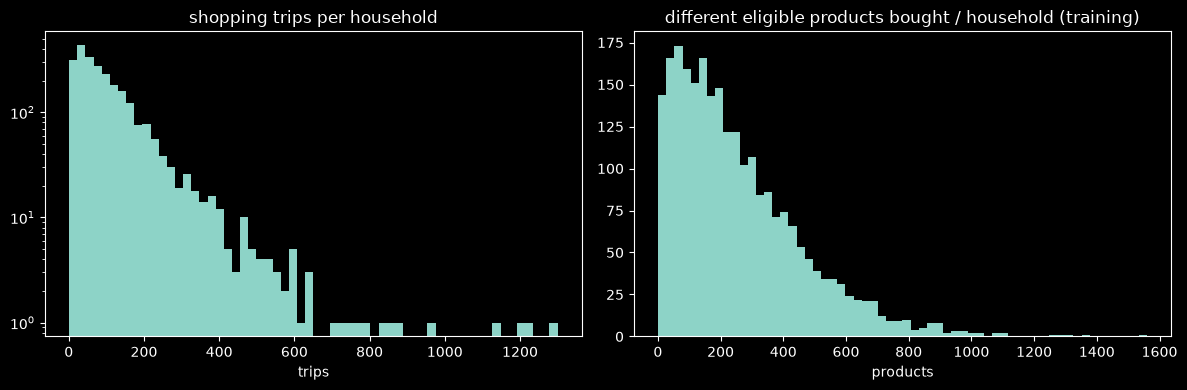

In [47]:
# baskets = distinct shopping trips per household (one BASKET_ID = one trip)
baskets = transactions.groupby("household_key")["BASKET_ID"].nunique()

# how many different coupon-eligible products each household bought while learning
elig_per_hh = train_tx_elig.groupby("household_key")["PRODUCT_ID"].nunique()

print("shopping trips per household (whole panel):")
print(baskets.describe()[["mean", "50%", "min", "max"]].round(1).to_string())
print(f"  < 10 trips  (barely shops): {(baskets < 10).sum():,}  ({(baskets < 10).mean():.1%})")   # little to learn from
print(f"  > 500 trips (very heavy)  : {(baskets > 500).sum():,}  ({(baskets > 500).mean():.1%})")  # could dominate a naive list
print("\ndifferent coupon-eligible products bought while learning, per household:")
print(elig_per_hh.describe()[["mean", "50%", "min", "max"]].round(1).to_string())

# left: trips per household (log scale to reveal the long tail); right: eligible products per household
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(baskets, bins=60); ax[0].set_yscale("log")
ax[0].set_title("shopping trips per household"); ax[0].set_xlabel("trips")
ax[1].hist(elig_per_hh, bins=60)
ax[1].set_title("different eligible products bought / household (training)"); ax[1].set_xlabel("products")
plt.tight_layout(); plt.show()

**In plain terms.** History is plentiful. A typical household made about 80 shopping trips over the two years and bought roughly 200 different coupon-eligible products during the learning period — more than enough to personalise from. Two small groups need a mental note: about 4% of households barely shopped (little to learn from), and about 1% shopped very heavily (their sheer volume would swamp a simple "most-bought overall" ranking unless we account for it).

## 5. Where is the demand, and are discounts distorting it?

Three checks that shape both the method and the honesty of the results:

- **5a — is demand concentrated or spread out?** If a few hundred products drive most sales, a plain "recommend the bestsellers" rule is hard to beat. If demand is spread across a long tail, personalisation has room to add value.
- **5b — how much of shopping is even coupon-eligible?** If coupons only touch a small corner of the basket, the exercise is niche. If they touch most of it, it is a mainstream lever.
- **5c — how often is a purchase already discounted?** If most "purchases" happen on promotion, then "they bought it" partly means "it was on offer" rather than "they wanted it" — which would weaken our claim that we are predicting genuine preference.

top   10 products = 4.8% of training purchase lines
top  100 products = 14.9% of training purchase lines
top 1000 products = 36.7% of training purchase lines


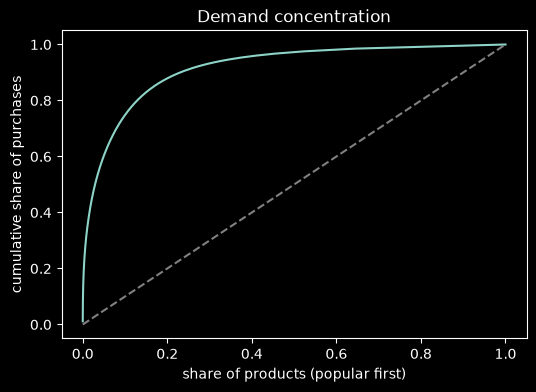

In [48]:
# 5a  demand concentration: what share of all purchase lines do the top-N products cover?
prod_freq = train_tx.groupby("PRODUCT_ID").size().sort_values(ascending=False)
cum = prod_freq.cumsum() / prod_freq.sum()
for n in (10, 100, 1000):
    print(f"top {n:>4} products = {cum.iloc[n - 1]:.1%} of training purchase lines")

# curve: x = share of products (most popular first), y = share of purchases they cover.
# a curve hugging the top-left = very concentrated; the diagonal = perfectly even.
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.arange(1, len(cum) + 1) / len(cum), cum.values)
ax.plot([0, 1], [0, 1], "--", color="grey")
ax.set_xlabel("share of products (popular first)")
ax.set_ylabel("cumulative share of purchases")
ax.set_title("Demand concentration")
plt.show()

In [49]:
# 5b  what fraction of training shopping is coupon-eligible - by number of lines, and by money spent?
elig_mask = train_tx["PRODUCT_ID"].isin(eligible)
print(f"coupon-eligible share of purchase lines : {elig_mask.mean():.1%}")
print(f"coupon-eligible share of money spent    : "
      f"{train_tx.loc[elig_mask, 'SALES_VALUE'].sum() / train_tx['SALES_VALUE'].sum():.1%}")

coupon-eligible share of purchase lines : 61.1%
coupon-eligible share of money spent    : 58.3%


In [50]:
# 5c  discounts on purchases:
#   RETAIL_DISC       = the retailer's own loyalty-card discount (routine)
#   COUPON_DISC       = a manufacturer coupon the shopper actually used
#   COUPON_MATCH_DISC = the retailer matching that coupon
disc_cols = ["RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"]
any_disc = (transactions[disc_cols] != 0).any(axis=1)

print(f"purchase lines with any discount           : {any_disc.mean():.1%}")
print(f"purchase lines with a manufacturer coupon  : {(transactions['COUPON_DISC'] != 0).mean():.2%}")
# the number that matters: how much of what we SCORE AGAINST was coupon-driven
print(f"test eligible purchases w/ a manuf. coupon : {(test_tx_elig['COUPON_DISC'] != 0).mean():.1%}")

purchase lines with any discount           : 50.8%
purchase lines with a manufacturer coupon  : 1.40%
test eligible purchases w/ a manuf. coupon : 1.6%


**In plain terms.** Demand is spread out — the 100 best-selling products account for only about 15% of purchases — so "just recommend the bestsellers" only goes so far, and there is real room for personalisation to do better. Coupon-eligible products make up about 60% of all shopping and of all money spent, so this is a mainstream problem, not a niche one. And although roughly half of purchases carry some discount, almost all of that is the routine loyalty-card discount: only about 1-2% involve an actual manufacturer coupon. So when a household buys a product in the test period, we can treat that as a real signal of what it wants, not a reaction to a promotion.

## 6. How does the retailer target coupons today?

Our recommender has to beat what the retailer already does, not a blank page. Two numbers describe the current approach:

- **How often do targeted households actually redeem?** If most sent coupons are ignored, there is clear room to do better.
- **Does the current targeting have any logic to it?** We compare the past spending of households the retailer chose for a campaign against the average household, in the product categories that campaign's coupons cover. A number above 1 means the retailer is already aiming campaigns at the right shoppers.

In [51]:
# how often does a household the retailer targeted redeem anything from that campaign?
campaign_table = pd.read_csv(DATA_DIR / "campaign_table.csv")   # who received which campaign
coupon_redempt = pd.read_csv(DATA_DIR / "coupon_redempt.csv")   # who redeemed what

assigned = set(zip(campaign_table["household_key"], campaign_table["CAMPAIGN"]))
redeemed = set(zip(coupon_redempt["household_key"], coupon_redempt["CAMPAIGN"]))

print(f"household-campaign pairs the retailer targeted : {len(assigned):,}")
print(f"...that redeemed at least one coupon           : {len(assigned & redeemed):,}  "
      f"({len(assigned & redeemed) / len(assigned):.1%})")

household-campaign pairs the retailer targeted : 7,208
...that redeemed at least one coupon           : 889  (12.3%)


In [52]:
# does the retailer's targeting have logic? for each campaign, compare targeted
# households' past category spend against the average household.
prod_cat   = product[["PRODUCT_ID", "COMMODITY_DESC"]]
campaign_coms = (coupon.merge(prod_cat, on="PRODUCT_ID", how="inner")
                 .groupby("CAMPAIGN")["COMMODITY_DESC"].apply(lambda s: set(s)))

hh_com = (train_tx.merge(prod_cat, on="PRODUCT_ID", how="inner")
          .groupby(["household_key", "COMMODITY_DESC"])["SALES_VALUE"].sum()
          .unstack(fill_value=0.0))
pop_mean = hh_com.mean(axis=0)   # average household spend per category

lifts = []
for cmp_id, coms in campaign_coms.items():
    coms = [c for c in coms if c in hh_com.columns]
    hh = [h for h in campaign_table.loc[campaign_table["CAMPAIGN"] == cmp_id, "household_key"].unique()
          if h in hh_com.index]
    if len(coms) == 0 or len(hh) < 5:
        continue
    lifts.append(hh_com.loc[hh, coms].to_numpy().mean() / pop_mean[coms].mean())

lifts = pd.Series(lifts)
print(f"campaigns analysed      : {len(lifts)}")
print(f"median targeting lift   : {lifts.median():.2f}x the average household's category spend")
print(f"campaigns with lift > 1 : {(lifts > 1).mean():.0%}")

campaigns analysed      : 30
median targeting lift   : 2.56x the average household's category spend
campaigns with lift > 1 : 100%


**In plain terms.** The retailer's current approach is a low but non-zero bar. Only about one in eight targeted household-campaign pairs redeems anything — most sent coupons are wasted. But the targeting is not random: households chosen for a campaign had already spent roughly 2.5x the average household in that campaign's categories. So the retailer does coarse, category-level targeting today; our job is to beat it with per-household, per-product personalisation.

## 7. Is the test period fair, and what does a "correct answer" look like?

Two things to settle before scoring anything.

**Is the hidden test period representative?** If those final weeks happened to contain a holiday spike or a slump, every method would score unusually high or low for reasons unrelated to quality. We compare both total sales and shopping-trip volume in the test weeks against the rest of the two years, and flag any week that is far from the norm.

**What does success mean in practice?** We describe the scoring task concretely: how many households we can actually score (they need at least one coupon-eligible purchase in the test period), whether those households have prior history, how many different products a household buys in the test period, and — importantly — how many of those are repeat buys of something already purchased versus brand-new products. That last split tells us whether a recommender can succeed just by replaying a household's habits, or whether it genuinely has to predict new behaviour.

test window (weeks 85-102) average weekly-sales z-score: +0.59
unusual weeks (|z| > 1.5): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 92]
  ...any in validation or test? [92]


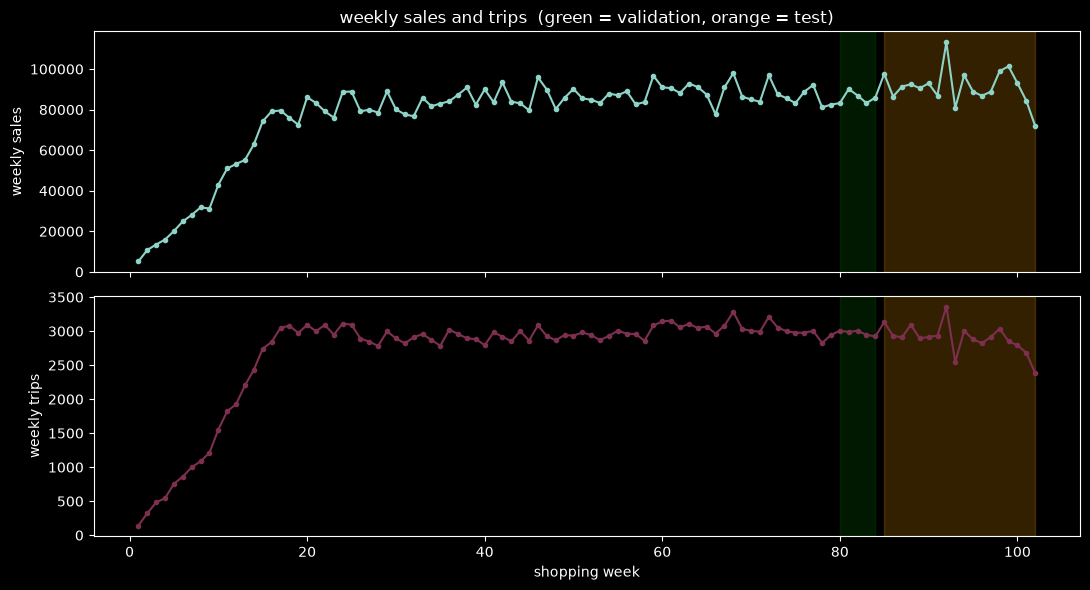

In [53]:
# Is the test period a normal stretch of shopping?
# We look at total sales AND number of shopping trips per week, and flag any week
# that is far from the two-year norm (|z| > 1.5).
weekly = transactions.groupby("WEEK_NO").agg(
    sales=("SALES_VALUE", "sum"), trips=("BASKET_ID", "nunique")
)
z = (weekly["sales"] - weekly["sales"].mean()) / weekly["sales"].std()
test_z  = z.loc[TEST_WEEKS].mean()
unusual = sorted(z[z.abs() > 1.5].index.tolist())

print(f"test window (weeks {TEST_WEEKS[0]}-{TEST_WEEKS[-1]}) average weekly-sales z-score: {test_z:+.2f}")
print(f"unusual weeks (|z| > 1.5): {unusual}")
print(f"  ...any in validation or test? {sorted(set(unusual) & set(VAL_WEEKS + TEST_WEEKS)) or 'no'}")

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(weekly.index, weekly["sales"], marker="o", ms=3); ax[0].set_ylabel("weekly sales")
ax[1].plot(weekly.index, weekly["trips"], marker="o", ms=3, color="#7d2f4f"); ax[1].set_ylabel("weekly trips")
for a in ax:
    a.axvspan(VAL_WEEKS[0], VAL_WEEKS[-1], color="green", alpha=0.2)
    a.axvspan(TEST_WEEKS[0], TEST_WEEKS[-1], color="orange", alpha=0.2)
ax[1].set_xlabel("shopping week")
ax[0].set_title("weekly sales and trips  (green = validation, orange = test)")
plt.tight_layout(); plt.show()

In [54]:
# For each household, the "correct answer" = the set of coupon-eligible products it
# bought during the test period.
gt_size = test_tx_elig.groupby("household_key")["PRODUCT_ID"].nunique()

eval_hh = set(gt_size.index)                                       # households we can score
warm_hh = set(train_tx_elig["household_key"].unique()) & eval_hh   # ...that also have history

print(f"households we can score (>=1 eligible purchase in test) : {len(eval_hh):,}")
print(f"  with prior history (warm) : {len(warm_hh):,}  ({len(warm_hh) / len(eval_hh):.1%})")
print(f"  no prior history  (cold)  : {len(eval_hh) - len(warm_hh):,}  ({1 - len(warm_hh) / len(eval_hh):.1%})")
print(f"products bought per household in test  median={gt_size.median():.0f}  "
      f"p25={gt_size.quantile(.25):.0f}  p75={gt_size.quantile(.75):.0f}  max={gt_size.max():.0f}")

# repeat vs first-time: was each test purchase also bought by that household while learning?
train_pairs = set(map(tuple, train_tx_elig[["household_key", "PRODUCT_ID"]].drop_duplicates().to_numpy()))
test_pairs  = test_tx_elig[["household_key", "PRODUCT_ID"]].drop_duplicates()
is_repeat   = pd.Series(list(map(tuple, test_pairs.to_numpy()))).isin(train_pairs)
print(f"\ntest purchases that repeat a training purchase : {is_repeat.mean():.1%}")
print(f"test purchases that are first-time (new)       : {1 - is_repeat.mean():.1%}")

households we can score (>=1 eligible purchase in test) : 2,364
  with prior history (warm) : 2,359  (99.8%)
  no prior history  (cold)  : 5  (0.2%)
products bought per household in test  median=69  p25=30  p75=130  max=538

test purchases that repeat a training purchase : 37.1%
test purchases that are first-time (new)       : 62.9%


**In plain terms.** The test period is broadly representative — its average weekly sales sit about half a standard deviation above the two-year mean, mostly because the first ~10 weeks (when the household panel was still being built up) drag that mean down. Those ramp-up weeks all fall in the training period. One week inside the test window (week 92) did have unusually high sales; because it is a spike rather than a gap, and every method is scored on exactly the same weeks, it does not change the comparison — but it is noted as a limitation.

We can score almost every household (about 2,360 of 2,500), and virtually all of them have prior history — so "cold start" (a household we know nothing about) is a non-issue here, which removes one common headache.

The scoring is demanding: over the test period a household buys around 70 different coupon-eligible products, and about 60% of those are products it had never bought before. A recommender that just replays each household's past favourites would therefore miss most of what actually happens — genuine prediction is required, not memory. Recommendations are allowed to include products a household already buys — a coupon for a staple is still a real offer — and an "exclude already-bought" variant is reported alongside, as a check that the model adds more than memory.

## 8. Summary and what to keep in mind

The figures below are rounded for a non-technical reader; the exact values are in the printed output of each section above. Both the table and the notes feed straight into the report.

| Topic | What we found | Why it matters |
|---|---|---|
| Size | ~2.6M purchase lines, 2,500 households, ~92,000 products, 2 years; files match the published dataset | enough data to model; small enough to run on a laptop; reproducible |
| Data quality | nothing missing, no duplicates, no broken links; ~1% odd lines excluded | no heavy cleaning needed; results are not distorted by bad records |
| What we can offer | ~44,000 coupon-eligible products; product grid ~99.3% empty, but ~34% full at the commodity level | a wide menu and thin evidence — a hard task; category level is a fallback signal |
| Household activity | ~4% barely shop, ~1% shop very heavily; a typical household has ~200 eligible products in its history | most households can be personalised; the extremes need handling |
| Demand and discounts | top 100 products ~= 15% of sales; ~60% of shopping is coupon-eligible; ~1-2% of purchases use a manufacturer coupon | bestsellers alone will not win; the problem is mainstream; purchases signal real preference |
| Retailer's targeting today | only ~12% of targeted household-campaign pairs redeem anything; targeted households had ~2.5x average category spend | the bar to beat is low but not zero — coarse category targeting exists, per-household does not |
| The scoring task | ~2,360 households scored, nearly all with history; ~70 products bought each in test; ~60% first-time | cold start is a non-issue; the model must predict new behaviour, not replay habits |

**Things to carry into the write-up**

1. **Household background details** (age, income, family) exist for only about a third of households, and those households spend noticeably more — so this information does not drive the model; at most it supports a side analysis.
2. **"Sales value" is what the retailer received after discounts, not the shopper's price** — this only matters if we later weight the model by spend or report a revenue figure.
3. **Only ~2% of test-period purchases involved a manufacturer coupon**, so "bought in the test period" is an almost-clean signal of genuine preference, not a promotion effect.
4. **Returns are excluded, not subtracted** — a return is not evidence a household dislikes a product.
5. **The retailer's current targeting is correlational, not proof of a specific algorithm** — treat the 2.5x lift as "the bar to clear", not as evidence of how the retailer chooses.
6. **One test week (week 92) had unusually high sales** (~1.6 standard deviations above the two-year average). It slightly enlarges the pool of purchases in the test window, but it affects every method equally, so it does not distort the comparison.
7. **This is an offline study.** We can show the recommender predicts future purchases better than a simple baseline; we cannot prove a coupon *caused* a purchase.